/tmp/ipykernel_4655/4019327486.py:101: RuntimeWarning: invalid value encountered in divide
  sfnr_img = signal_img / fluctuation_noise_img


The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
The date format is not correct, trying another order.
[1196.19676562 1211.25954687 1188.4803125  1182.093875   1175.31817188
 1183.11678125 1164.49021875 1182.90323438 1141.30314062 1145.684

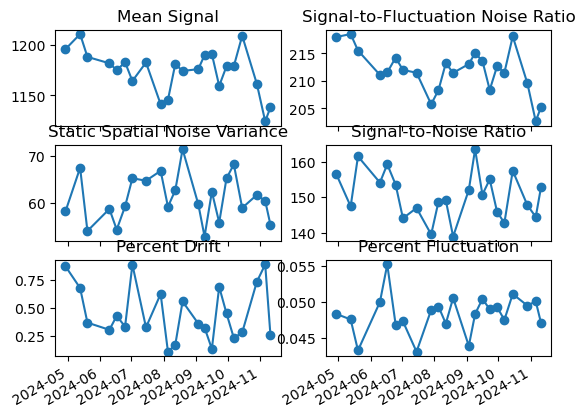

In [2]:
import nibabel as nib
import nilearn as nil
import scipy.ndimage as ndi
from scipy.fft import fft, fftfreq
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.dates as mdates
import numpy as np
import os
import glob
import re
from datetime import datetime

subject_dir = "/mnt/d/CINL/QA2024/scratch/out/bids/sub-fbirn"

mean_signal_values = np.zeros(len(os.listdir(subject_dir)))
sfnr_values = np.zeros(len(os.listdir(subject_dir)))
ssnvar_values = np.zeros(len(os.listdir(subject_dir)))
snr_values = np.zeros(len(os.listdir(subject_dir)))
percent_drift_values = np.zeros(len(os.listdir(subject_dir)))
percent_fluctuation_values = np.zeros(len(os.listdir(subject_dir)))

dates = []

for index, session_dir in enumerate(glob.glob(os.path.join(subject_dir, 'ses-Qa*'))):
    nii_file = glob.glob(os.path.join(subject_dir, session_dir, 'func', '*.nii.gz'))
    fates = nib.load(nii_file[0])

    # get the date string from the session directory
    match = re.search(r'\d{8}', nii_file[0])
    if match:
        date_str = match.group()
        try:
            dates.append(datetime.strptime(date_str, '%m%d%Y'))
        except ValueError:
            print("The date format is not correct, trying another order.")
            try:
                dates.append(datetime.strptime(date_str, '%Y%m%d'))
            except ValueError:
                print("The date format is not correct.")

    else:
        print("No 8-digit date string found.")

    # request array data from proxy images
    fates_data = fates.get_fdata()

    # get the size of each dimension in the data array
    x_dim, y_dim, z_dim, t_dim = fates_data.shape

    # region of interest
    roi_x, roi_y, roi_z = 49, 63, 23
    roi_size = 20
    half_size = roi_size // 2

    # coordinate of center slice is roi_z

    # define the bounds of the region of interest and ensure they stay within the image bounds
    x_min = max(roi_x - half_size, 0)
    x_max = min(roi_x + half_size, x_dim - 1)
    y_min = max(roi_y - half_size, 0)
    y_max = min(roi_y + half_size, y_dim - 1)
    # z_min = max(roi_z - half_size, 0)
    # z_max = min(roi_z + half_size, z_dim - 1)

    # ------- MEAN SIGNAL -------
    # calculate signal image (simple average)
    # take center slice only
    signal_img = np.mean(fates_data[:,:,roi_z,:], axis=2)
    # signal summary value
    mean_signal_values[index] = np.mean(signal_img[x_min:x_max, y_min:y_max])

    # ------- FLUCTUATION NOISE -------
    # calculate temporal fluctuation noise image
    # center slice only
    # Initialize an array to store the standard deviation of residuals
    fluctuation_noise_img = np.zeros((x_dim, y_dim))

    # Loop through each voxel
    for i in range(x_dim):
        for j in range(y_dim):
            # Extract the time-series for the current voxel
            time_series = fates_data[i, j, roi_z, :]

            # Fit a second-order polynomial
            time_points = np.arange(t_dim)
            coefficients = np.polyfit(time_points, time_series, 2)
            polynomial = np.poly1d(coefficients)

            # Calculate the residuals (original - fitted)
            fitted_values = polynomial(time_points)
            residuals = time_series - fitted_values

            # Calculate the standard deviation of the residuals
            fluctuation_noise_img[i, j] = np.std(residuals)

    # SIGNAL-TO-FLUCTUATION-NOISE RATIO (SFNR) IMAGE
    # voxelwise division of signal and temporal fluctuation noise image
    sfnr_img = signal_img / fluctuation_noise_img
    # summary SFNR value from ROI
    sfnr_values[index] = np.mean(sfnr_img[x_min:x_max, y_min:y_max])

    # STATIC SPATIAL NOISE IMAGE
    sumEven_img = np.sum(fates_data[:, :, roi_z, 0:2:t_dim], axis=2)
    sumOdd_img = np.sum(fates_data[:, :, roi_z, 1:2:t_dim], axis=2)
    diff_img = sumOdd_img - sumEven_img
    # static spatial noise variance summary value
    ssnvar_values[index] = np.var(diff_img[x_min:x_max, y_min:y_max])

    snr_values[index] = mean_signal_values[index] / np.sqrt(ssnvar_values[index])

    # --- DETRENDING ---
    # initialize array to store average roi values
    averages = np.zeros(fates_data.shape[3])

    # compute average of each time point
    for t in range(fates_data.shape[3]):
        region = fates_data[x_min:x_max+1, y_min:y_max+1, roi_z, t]
        averages[t] = np.mean(region)

    # mean signal intensity
    signal_intensity = np.mean(averages)

    # fit polynomal for detrending
    time_points = np.arange(len(averages))
    degree = 2
    coefficients = np.polyfit(time_points, averages, degree)
    p = np.poly1d(coefficients)

    # evaluate polynomial over time range
    t_fit = np.linspace(time_points.min(), time_points.max(), 160)
    y_fit = p(t_fit)

    # calculate residuals (detrended data)
    residuals = averages - y_fit

    # ------- PERCENT DRIFT -------
    percent_drift_values[index] = (max(y_fit) - min(y_fit)) / signal_intensity * 100
    
    # ------- PERCENT FLUCTUATION -------
    percent_fluctuation_values[index] = 100 * np.std(residuals) / signal_intensity

print(mean_signal_values)
print(sfnr_values)
print(ssnvar_values)
print(snr_values)
print(percent_drift_values)
print(percent_fluctuation_values)
print(dates)

combined = list(zip(dates, mean_signal_values, sfnr_values, ssnvar_values, snr_values, percent_drift_values, percent_fluctuation_values))
combined.sort()
sorted_dates, sorted_mean_signal_values, sorted_sfnr_values, sorted_ssnvar_values, sorted_snr_values, sorted_percent_drift_values, sorted_percent_fluctuation_values = zip(*combined)
print(sorted_dates)
print(sorted_mean_signal_values)

fig, axs = plt.subplots(3, 2, sharex=True)
axs[0,0].plot(sorted_dates, sorted_mean_signal_values, marker='o')
axs[0,0].set_title("Mean Signal")
axs[0,1].plot(sorted_dates, sorted_sfnr_values, marker='o')
axs[0,1].set_title("Signal-to-Fluctuation Noise Ratio")
axs[1,0].plot(sorted_dates, sorted_ssnvar_values, marker='o')
axs[1,0].set_title("Static Spatial Noise Variance")
axs[1,1].plot(sorted_dates, sorted_snr_values, marker='o')
axs[1,1].set_title("Signal-to-Noise Ratio")
axs[2,0].plot(sorted_dates, sorted_percent_drift_values, marker='o')
axs[2,0].set_title("Percent Drift")
axs[2,1].plot(sorted_dates, sorted_percent_fluctuation_values, marker='o')
axs[2,1].set_title("Percent Fluctuation")
plt.gcf().autofmt_xdate()
plt.show()